In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

Load data

In [162]:
# Load the file
df = pd.read_csv(r"Sivert\Lab 3\Lab 3\Første sett\trans3.txt", sep=r"\s+", header=None)
df.columns = ["Red", "Green", "Blue"]

# Time axis
time = np.linspace(0, 30, len(df))
dt = time[1] - time[0]          # sampling interval
N = len(df)                     # number of samples

TIME DOMAIN PLOT

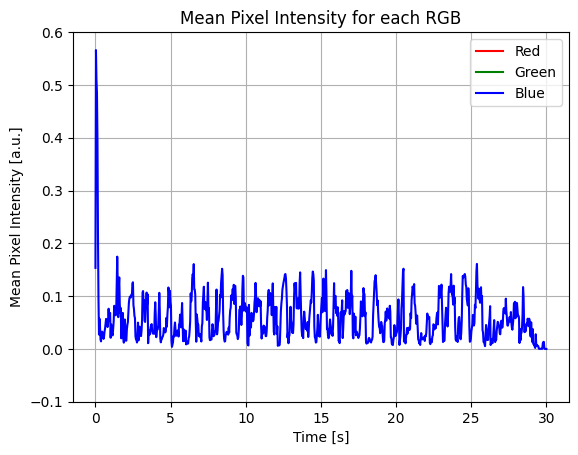

In [163]:
for col in df.columns:
    plt.plot(time, df[col], label=col, color=col[0].lower())

plt.title("Mean Pixel Intensity for each RGB")
plt.xlabel("Time [s]")
plt.ylabel("Mean Pixel Intensity [a.u.]")
plt.ylim(-0.1,0.6)
plt.legend()
plt.grid(True)
plt.show()

FFT

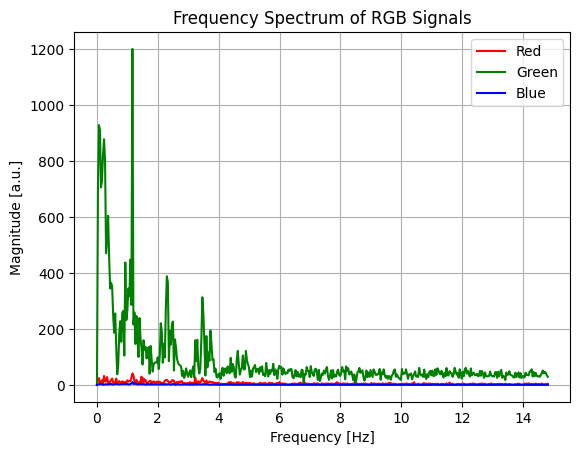

In [164]:
fft_mag_all = []
freqs_all = []
for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)

    fft_vals = np.fft.fft(signal_demeaned)
    freqs = np.fft.fftfreq(N, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])
    fft_mag_all.append(fft_mag)
    freqs_all = freqs_pos

    plt.plot(freqs_pos, fft_mag, label=f"{col}", color=col[0].lower())

plt.legend()    
plt.title("Frequency Spectrum of RGB Signals")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
#plt.xlim(0,4)
#plt.ylim(0,60)
plt.grid(True)
plt.show()

FFT WITH FILTER, ZERO PADDING, AND WINDOWING

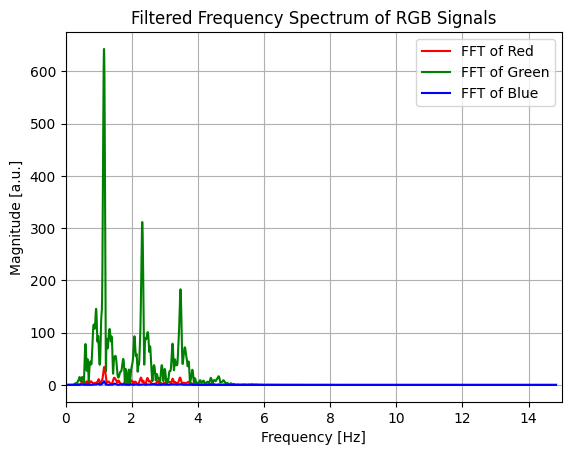

In [165]:
Nfft = N*8
fs = 30
lower_limit = 0.5
upper_limit = 4.0
b, a = butter(3, [lower_limit/(fs/2) , upper_limit/(fs/2)], btype='band')
window = np.hanning(N)

fft_mag_filtered_all = []
freqs_filtered_all = []
for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)
    signal_filtered = filtfilt(b, a, signal_demeaned * window)

    fft_vals = np.fft.fft(signal_filtered, n=Nfft)
    freqs = np.fft.fftfreq(Nfft, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])
    fft_mag_filtered_all.append(fft_mag)
    freqs_filtered_all = freqs_pos

    plt.plot(freqs_pos, fft_mag, label = f"FFT of {col}", color=col[0].lower())

plt.legend()    
plt.title("Filtered Frequency Spectrum of RGB Signals")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
plt.xlim(0,15)
plt.grid(True)
plt.show()

FIND PULSE

In [166]:
def find_pulsefrequency(magnitude, freq):
    relevant_indices = np.where((freq >= lower_limit) & (freq <= upper_limit))
    relevant_magnitude = magnitude[relevant_indices]
    relevant_freq = freq[relevant_indices]

    if len(relevant_magnitude) == 0:
        return None  # Ingen relevante frekvenser funnet

    max_index = np.argmax(relevant_magnitude)
    pulsefrequency = relevant_freq[max_index]
    
    return freq[np.argmax(magnitude)]
    return pulsefrequency


In [167]:
#--Before filter--
pulsefrequency_red_before = find_pulsefrequency(fft_mag_all[0], freqs_all)
pulsefrequency_green_before = find_pulsefrequency(fft_mag_all[1], freqs_all)
pulsefrequency_blue_before = find_pulsefrequency(fft_mag_all[2], freqs_all)
print(f"Plusefrequency before filter (Red): {pulsefrequency_red_before * 60:.2f} BPM")
print(f"Plusefrequency before filter (Green): {pulsefrequency_green_before * 60:.2f} BPM")
print(f"Plusefrequency before filter (Blue): {pulsefrequency_blue_before * 60:.2f} BPM")

#--After filter--
pulsefrequency_red = find_pulsefrequency(fft_mag_filtered_all[0], freqs_filtered_all)
pulsefrequency_green = find_pulsefrequency(fft_mag_filtered_all[1], freqs_filtered_all)
pulsefrequency_blue = find_pulsefrequency(fft_mag_filtered_all[2], freqs_filtered_all)
print(f"\nPulsefrequency after filter (Red): {pulsefrequency_red * 60:.2f} BPM")
print(f"Pulsefrequency after filter (Green): {pulsefrequency_green * 60:.2f} BPM")
print(f"Pulsefrequency after filter (Blue): {pulsefrequency_blue * 60:.2f} BPM")

Plusefrequency before filter (Red): 69.92 BPM
Plusefrequency before filter (Green): 69.92 BPM
Plusefrequency before filter (Blue): 69.92 BPM

Pulsefrequency after filter (Red): 70.17 BPM
Pulsefrequency after filter (Green): 69.67 BPM
Pulsefrequency after filter (Blue): 69.67 BPM


SNR (Need to fix!)

In [168]:
pulse_real = 62  
Pulse_freq = pulse_real / 60  #Example: 60 BPM is 1 Hz
Measured_pluse_freq = pulsefrequency_green  

freq_tolerance = 0.1  # In Hz

#[pulse_frequency - frequency_tolerance, .., .., pulse_frequency + frequency_tolerance]
signal_indices_before = np.where((freqs_all >= Measured_pluse_freq - freq_tolerance) & 
                          (freqs_all <= Measured_pluse_freq + freq_tolerance))[0]

signal_indices_filtered = np.where((freqs_filtered_all >= Measured_pluse_freq - freq_tolerance) & 
                          (freqs_filtered_all <= Measured_pluse_freq + freq_tolerance))[0]

power_red_before = (fft_mag_all[0]**2) / N**2
power_green_before = (fft_mag_all[1]**2) / N**2
power_blue_before = (fft_mag_all[2]**2) / N**2

power_red_filtered = (fft_mag_filtered_all[0]**2) / N**2
power_green_filtered = (fft_mag_filtered_all[1]**2) / N**2
power_blue_filtered = (fft_mag_filtered_all[2]**2) / N**2

In [169]:
#---Before filtering--- 
signal_power_red_before = np.mean(power_red_before[signal_indices_before])
signal_power_green_before = np.mean(power_green_before[signal_indices_before])
signal_power_blue_before = np.mean(power_blue_before[signal_indices_before])

noise_power_red_before = np.mean(np.delete(power_red_before, signal_indices_before))
noise_power_green_before = np.mean(np.delete(power_green_before, signal_indices_before))
noise_power_blue_before = np.mean(np.delete(power_blue_before, signal_indices_before))

SNR_red_before = 10 * np.log10(signal_power_red_before / noise_power_red_before)
SNR_green_before = 10 * np.log10(signal_power_green_before / noise_power_green_before)
SNR_blue_before = 10 * np.log10(signal_power_blue_before / noise_power_blue_before)

print("\nSNR before filter:")
print(f"Red: {SNR_red_before:.2f} dB")
print(f"Green: {SNR_green_before:.2f} dB")
print(f"Blue: {SNR_blue_before:.2f} dB")


SNR before filter:
Red: 11.00 dB
Green: 11.58 dB
Blue: 13.29 dB


In [170]:
#---After filtering---
signal_power_red_filtered = np.mean(power_red_filtered[signal_indices_filtered])
signal_power_green_filtered = np.mean(power_green_filtered[signal_indices_filtered])
signal_power_blue_filtered = np.mean(power_blue_filtered[signal_indices_filtered])

noise_power_red_filtered = np.mean(np.delete(power_red_filtered, signal_indices_filtered))
noise_power_green_filtered = np.mean(np.delete(power_green_filtered, signal_indices_filtered))
noise_power_blue_filtered = np.mean(np.delete(power_blue_filtered, signal_indices_filtered))

SNR_red_filtered = 10 * np.log10(signal_power_red_filtered / noise_power_red_filtered)
SNR_green_filtered = 10 * np.log10(signal_power_green_filtered / noise_power_green_filtered)
SNR_blue_filtered = 10 * np.log10(signal_power_blue_filtered / noise_power_blue_filtered)

print("\nSNR after filtrering:")
print(f"Red: {SNR_red_filtered:.2f} dB")
print(f"Green: {SNR_green_filtered:.2f} dB")
print(f"Blue: {SNR_blue_filtered:.2f} dB")


SNR after filtrering:
Red: 17.10 dB
Green: 20.02 dB
Blue: 19.55 dB


In [171]:
Transmittance = []
Reflectance = []

mean_transmittance = np.mean(Transmittance)
variance_transmittance = np.var(Transmittance)
std_deviation_transmittance = np.sqrt(variance_transmittance)

mean_reflectance = np.mean(Reflectance)
variance_reflectance = np.var(Reflectance)
std_deviation_transmittance = np.sqrt(variance_reflectance)


print("Transmittance")
print(f"Mean: {mean_transmittance} m/s")
print(f"Variance: {variance_transmittance} (m/s)^2")
print(f"Standard Deviation: {std_deviation_transmittance} m/s")

print("\n\nSpeed X forwards")
print(f"Mean: {mean_reflectance} m/s")
print(f"Variance: {variance_reflectance} (m/s)^2")
print(f"Standard Deviation: {std_deviation_transmittance} m/s")

Transmittance
Mean: nan m/s
Variance: nan (m/s)^2
Standard Deviation: nan m/s


Speed X forwards
Mean: nan m/s
Variance: nan (m/s)^2
Standard Deviation: nan m/s


c:\Users\krita\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\krita\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\krita\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\krita\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\krita\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dt